# Recommended workflow: SEACells end-to-end + downstream sanity

This is the **default tutorial** for users new to `ov.single.MetaCell`.  We
run the recommended backend (`'seacells'`) on a typical single-sample
dataset and immediately drive it into the two most common downstream
analyses — differential expression and marker-dotplot — to show that the
metacell-level AnnData is a drop-in replacement for the cell-level one.

After this notebook:

- Run `t_metacell_multisample` if you have ≥2 samples / batches.
- Browse [zoo/index](zoo/index.md) if you want to swap out the backend
  (faster: `kmeans` / `supercell`; out-of-sample: `metaq`; sanity floor:
  `random`).

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import omicverse as ov
import scvelo as scv   # demo dataset only

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Load and preprocess

Standard omicverse flow: qc → preprocess → scale → pca → neighbors → umap.
SEACells builds its kernel on a low-dim embedding (here `X_pca`).

In [2]:
adata = scv.datasets.pancreas()
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.20, 'nUMIs': 500, 'detected_genes': 250},
                 mt_startswith='mt-')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000)
adata.layers['lognorm'] = adata.X.copy()
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
ov.pp.umap(adata)
print('adata:', adata.shape, 'celltypes:', sorted(adata.obs['clusters'].unique()))

  0%|          | 0.00/50.0M [00:00<?, ?B/s]

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

   ✓ Final filtering: 0 cells, 12,261 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.387
   ✓ scDblFinder completed: 66 doublets removed (1.8%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 16.3196s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ 

🔍 [2026-05-19 18:11:12] Running preprocessing in 'cpu' mode...
Begin robust gene identification


...


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.65s                                                   │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3630x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3630, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.52s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.5298s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3630x30)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.8089s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 18:11:25] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distan


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 1.0204s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
adata: (3630, 2000)

## 3. Fit SEACells

`n_metacells = adata.n_obs // 50` is a reasonable starting point — it gives
~70–80 metacells per 4 k cells, with mean metacell size ~50 cells.


In [3]:
mc = ov.single.MetaCell(
    adata.copy(), method='seacells',
    n_metacells=adata.n_obs // 50,
    use_rep='X_pca', device='cpu', random_state=0,
).fit()
print(f'fit done: n_metacells={mc.n_metacells}, '
      f'runtime={mc._fit_result.runtime_s:.2f} s, '
      f'capabilities={sorted(mc.capabilities)}')

Welcome to SEACells!


  0%|          | 0/3630 [00:00<?, ?it/s]

Parameter graph_construction = union being used to build KNN graph...


  0%|          | 0/3630 [00:00<?, ?it/s]

  0%|          | 0/3630 [00:00<?, ?it/s]

Building kernel on X_pca


  0%|                                                                                                                      | 0/14 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 471.93it/s]

fit done: n_metacells=72, runtime=12.99 s, capabilities=['latent', 'soft']


## 4. Aggregate to a metacell AnnData

In [4]:
# 'sum' aggregation preserves raw-count totals — required by SCENIC / pseudobulk
# DE / CellPhoneDB. Use 'mean' for visualization-only workflows.
ad_mc = mc.predicted(method='soft', layer='counts', summary='sum',
                     celltype_label='clusters')
print(f'metacell AnnData: {ad_mc.shape}')
print(f'  mean cells/metacell: {ad_mc.obs["n_cells"].mean():.1f}')
print(f'  mean purity        : {ad_mc.obs["clusters_purity"].mean():.3f}')
ad_mc.obs.head()

metacell AnnData: (72, 2000)
  mean cells/metacell: 111.4
  mean purity        : 0.877


,n_cells,clusters,clusters_purity
mc-0,200,Alpha,0.979167
mc-1,45,Epsilon,1.000000
mc-2,152,Ngn3 high EP,0.894737
mc-3,112,Epsilon,0.904762
mc-4,92,Ductal,0.967742


## 5. Quality check: purity / separation / compactness

These three SEACells-style metrics apply to *any* metacell partition.  All
three are computed in one helper call and the histograms tell you whether
the partition is honest.

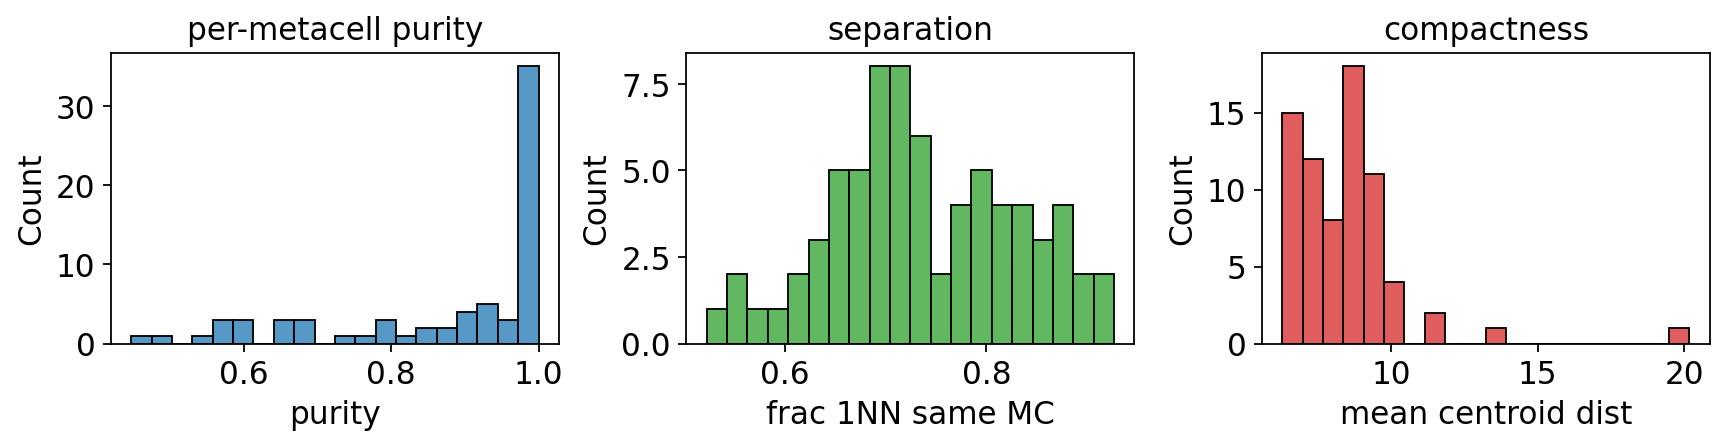

In [5]:
purity, separation, compactness = ov.pl.metacell_metrics(
    mc, label_key='clusters', use_rep='X_pca',
)

## 6. mcRigor: statistical validation

Asks per metacell: *is its gene–gene covariance larger than expected from a
within-cell gene-shuffle null at this metacell size?*  Metacells whose
`mcDiv` exceeds the size-stratified threshold are flagged as `'dubious'`.
Lower `dubious_rate` → tighter metacells.

In [6]:
rep = mc.check_rigor(layer_lognorm='lognorm', n_rep=30,
                     feature_use=1000, random_state=0)
print(f'rigor_score : {rep.score:.3f}')
print(f'dubious_rate: {rep.dubious_rate:.3f}')
print(f'zero_rate   : {rep.zero_rate:.3f}')

rigor_score : 0.568
dubious_rate: 0.621
zero_rate   : 0.243


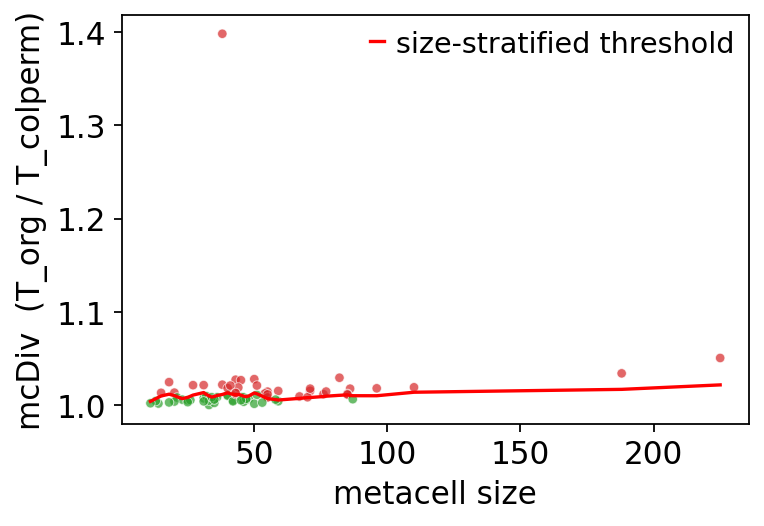

<Axes: xlabel='metacell size', ylabel='mcDiv  (T_org / T_colperm)'>

In [7]:
ov.pl.rigor_scatter(rep)

## 7. Visualize: metacell centroids on the source UMAP

Centroids inside clearly-coloured cell-type islands = good metacells.
Centroids straddling cell-type boundaries → mixed metacells (high
mcDiv, low purity).

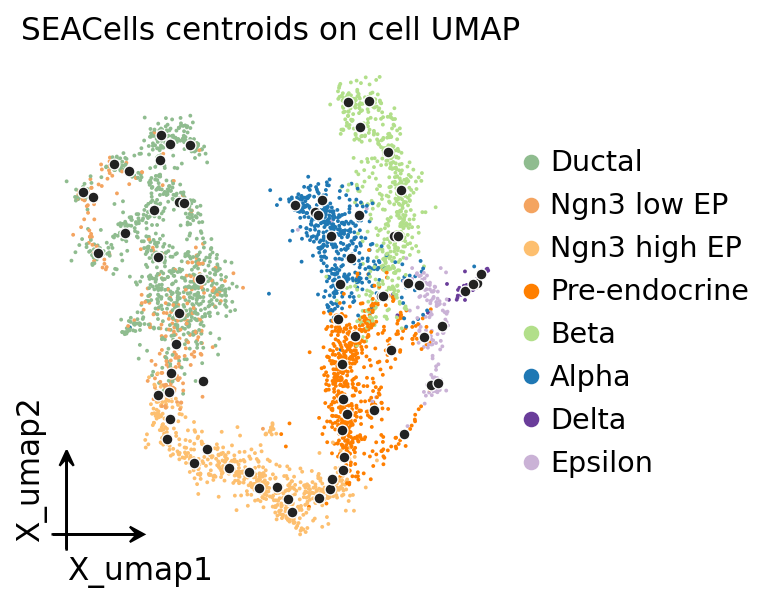

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
ov.pl.embedding(mc.adata, basis='X_umap', color='clusters', ax=ax, show=False,
                frameon='small', title='SEACells centroids on cell UMAP', size=12)
labels = mc._fit_result.assignments
pts = np.array([mc.adata.obsm['X_umap'][labels == u].mean(axis=0)
                for u in np.unique(labels)])
ax.scatter(pts[:, 0], pts[:, 1], s=24, c='#222',
           edgecolors='white', linewidths=0.6, zorder=5)
plt.tight_layout(); plt.show()

## 8. Visualize: metacell-level UMAP

A common downstream use of metacells is to **treat them as a much smaller
atlas** — re-run the standard preprocess → PCA → UMAP loop on the
aggregated AnnData.  Celltype structure should survive cleanly.

🔍 [2026-05-19 18:12:08] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 72 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_ran

   🔧 PCA solver used: covariance_eigh
    finished✅ (1.00s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.0111s                                                 │
│  Shape:    72 x 2,000 (Unchanged)                                  │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 72x30)                                 │
│           │ ✚ scaled|original|X_pca (array, 72x30)                 │
│         

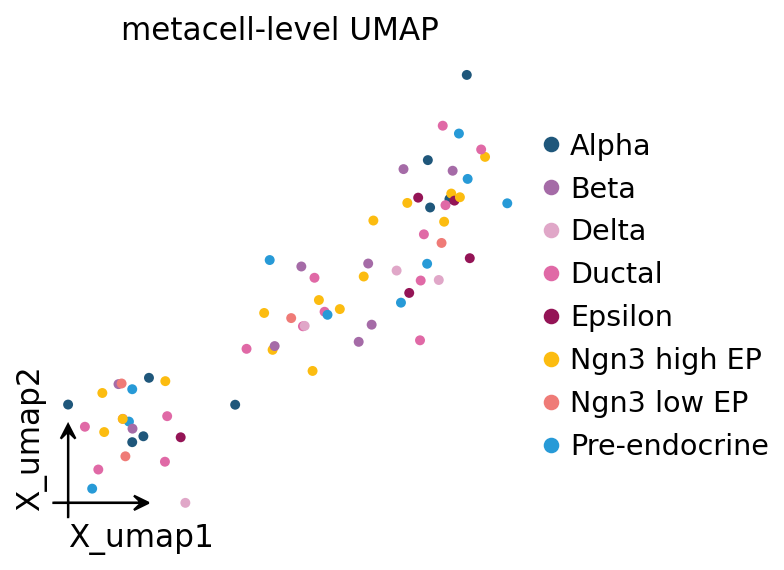

In [9]:
ad_mc = ov.pp.preprocess(ad_mc, mode='shiftlog|pearson',
                          n_HVGs=min(2000, ad_mc.n_vars))
ad_mc = ad_mc[:, ad_mc.var.highly_variable_features]
ov.pp.scale(ad_mc)
ov.pp.pca(ad_mc, layer='scaled', n_pcs=min(30, ad_mc.n_obs - 1))
ad_mc.obsm['X_pca'] = ad_mc.obsm['scaled|original|X_pca']
ov.pp.neighbors(ad_mc, n_neighbors=min(15, ad_mc.n_obs - 1), use_rep='X_pca')
ov.pp.umap(ad_mc)
ov.pl.embedding(ad_mc, basis='X_umap', color='clusters',
                frameon='small', title='metacell-level UMAP', size=80)

## 9. Downstream task 1 — differential expression

Find marker genes per celltype on the metacell AnnData using
`ov.single.find_markers` (the omicverse Wilcoxon wrapper with `pts=True`
for per-cluster expression fractions).

In [10]:
# Drop celltypes with <2 metacells (find_markers needs n>=2 per group).
counts = ad_mc.obs['clusters'].value_counts()
keep = counts[counts >= 2].index.tolist()
ad_mc_de = ad_mc[ad_mc.obs['clusters'].isin(keep)].copy()
ad_mc_de.obs['clusters'] = ad_mc_de.obs['clusters'].astype('category')

ov.single.find_markers(ad_mc_de, groupby='clusters', method='wilcoxon',
                       key_added='rank_genes_groups', pts=True, use_gpu=False)
ov.single.get_markers(ad_mc_de, n_genes=3, key='rank_genes_groups')

🔍 Finding marker genes | method: wilcoxon | groupby: clusters | n_groups: 8 | n_genes: 50
✅ Done | 8 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']


,group,rank,names,scores,logfoldchanges,pvals,pvals_adj,pct_group,pct_rest
0,Alpha,1,Rcn3,3.533099,2.422065,0.000411,0.655731,1.000000,0.904762
1,Alpha,2,Rap1gapos,3.107424,1.753251,0.001887,0.655731,1.000000,0.968254
2,Alpha,3,Ccnd2,2.920127,1.736997,0.003499,0.655731,1.000000,1.000000
3,Beta,1,Xist,2.954181,0.334937,0.003135,0.994202,1.000000,1.000000
4,Beta,2,Foxo3,2.596615,0.624580,0.009415,0.994202,1.000000,1.000000
5,Beta,3,Fitm1,2.392291,1.633196,0.016744,0.994202,0.888889,0.809524
6,Delta,1,Tpbg,2.114186,1.001293,0.034499,0.997850,1.000000,0.985294
7,Delta,2,Egr1,2.065019,0.439004,0.038921,0.997850,1.000000,1.000000
8,Delta,3,H1f0,1.917518,0.585268,0.055172,0.997850,1.000000,1.000000
9,Ductal,1,Ube2e3,2.183870,0.346871,0.028972,0.995464,1.000000,1.000000


## 10. Downstream task 2 — marker dotplot

`ov.pl.markers_dotplot` reads the `rank_genes_groups` result and shows the
top-N markers per group with both expression intensity (colour) and the
fraction of metacells in which each gene is expressed (dot size).
Canonical pancreas markers (Ins1/Ins2 for Beta, Gcg for Alpha, etc.)
should pop out clearly even on this small metacell set.

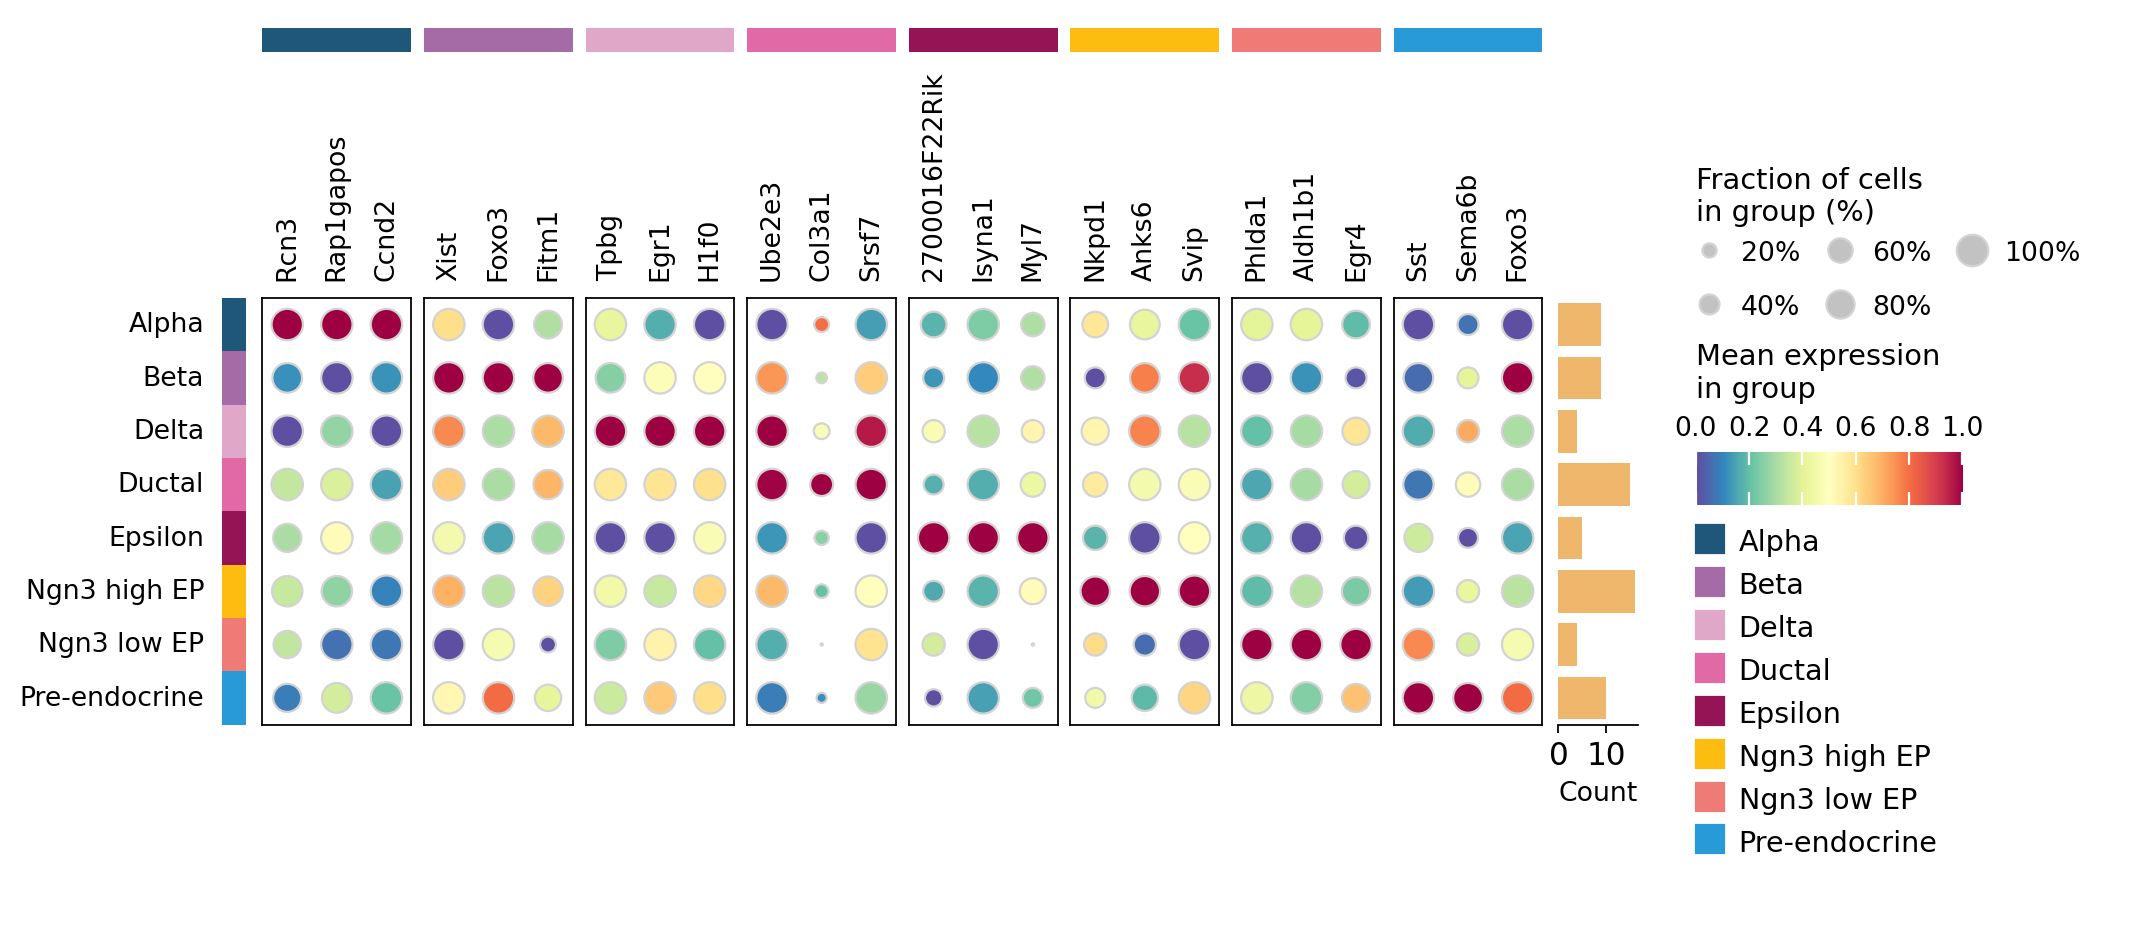

In [11]:
ov.pl.markers_dotplot(ad_mc_de, groupby='clusters', n_genes=3,
                      key='rank_genes_groups')

## 11. Save the metacell partition

Save the slim state (assignments + soft membership + config).  The
companion `load` recovers the unified AnnData schema and lets you re-run
`predicted()` / `compute_purity()` / etc. without re-fitting.

In [12]:
import tempfile, os
with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
    path = f.name
mc.save(path)
print(f'saved to {path}')
os.remove(path)

saved to /tmp/tmpvb36k_pi.pkl


## 12. Next steps

- **Multi-sample data?**  Move on to
  [t_metacell_multisample](t_metacell_multisample.ipynb) — same workflow
  but with batch correction first so per-sample metacells live in a shared
  embedding.
- **Need out-of-sample assignment** (new cells arrive over time)?  Switch
  the backend to `metaq` and use `mc.assign_new_cells(adata_new)` — see
  [zoo/t_metacell_metaq](zoo/t_metacell_metaq.ipynb).
- **Want to validate the choice of backend?**  Run
  `ov.single.compare_metacell_backends` on your data — see
  [zoo/t_metacell_compare](zoo/t_metacell_compare.ipynb).
- **Want to use metacells in cell–cell communication / SCENIC?**  Pass
  `ad_mc` (the AnnData returned by `mc.predicted()`) into the standard
  `ov.single.pCellPhoneDB`, `ov.single.pySCENIC`, etc. workflows — they
  consume the unified schema directly.